# Solving 9×9 Sudoku via geometry-of-interaction

A Sudoku grid is a **closed combinatorial map**: one box per cell, each wired to
the cells it must differ from. Calling the map runs synchronous message passing
along the wires, and that iteration *is* the **execution formula** of the
geometry of interaction (GoI) unrolled in
time. Solving the puzzle means letting the messages flow until the map settles
into the unique fixed point the clues pin down. We find that one tiny, grid-size-independent cell, iterated over the grid,
solves most given puzzles. Interestingly, we found that running more rounds at inference than we trained on is by far the most impactful choice  (here $0.28\to0.81$ solved boards, just by
iterating longer at test time). Also, encoding each Sudoku unit as *one* constraint box
(a factor graph) beats the pairwise encoding with **half the wires**.

## 1. The construction

**Objects and wires.** `discopy.neural` is a compact-closed category whose
objects are `Dim`s (wire widths) and whose morphisms are bidirectional networks.
Compact closure makes every object self-dual (`Dim(n).l == Dim(n).r == Dim(n)`):
a wire has no fixed orientation, so each port of a box both sends a message
and receives one. **A combinatorial map** is a finite family of boxes $(f_1,\dots,f_n)$ together
with a **fixpoint-free involution** $\sigma$ on their ports. Stack all port messages into one state
$m$. A single round of message passing is

$$ m \;\longmapsto\; F(m) \;=\; \sigma\,\big(f_1 \oplus \cdots \oplus f_n\big)(m), $$

i.e. *every box fires in parallel on its current inputs, then $\sigma$ slides
each output along its wire to become the next input. Iterating $F$ and reading the wires
that leave the map is GoI's execution formula $\mathrm{Ex}(f)=\mathrm{Tr}(f)$:
the trace that feeds a morphism's outputs back into its inputs, whose value is the
sum over all paths a message can travel. Pinning the clues and running $F$ to
convergence solves the equation $m^\star = F(m^\star)$. Intuitively, each cell keeps telling its peers "here is what I might be" and listens back; after enough rounds the guesses settle into a consistent grid. Categorically, the grid is an endomorphism $I \to I$ obtained by tracing a
shared cell over the peer wiring; a well-posed (unique-solution) puzzle is one
whose traced map has a **unique fixed point**, and message passing is the
iteration that seeks it.

In [1]:
# Setup: imports, a consistent seaborn/matplotlib theme, and fixed seeds so the
# whole notebook is reproducible. We auto-select the GPU when one is available.
# QUICK trades runtime for accuracy (the pairwise `peers` model dominates the cost),
# and DATA is the folder where the generated puzzle splits are cached.

import os, time
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from discopy.neural import *

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("discopy.neural on", device)

QUICK = False
DATA = os.environ.get("SUDOKU_DATA", "sudoku_data")
os.makedirs(DATA, exist_ok=True)

discopy.neural on cuda




We draw both constructions that will be used in this notebook at 4×4 (the 9×9 grids are
  the same constructions at 81 cells): the `peers` map wires every pair of peers
  directly (a clique per unit), while the `constraints` map adds one box per
  row/column/block and wires each cell only to its three units — a bipartite factor
  graph with fewer wires. Solving either is running its message passing, the
  execution formula of §1, to the fixed point the clues pin down.

peers       : 16 boxes, 56 wires, non-planar: True


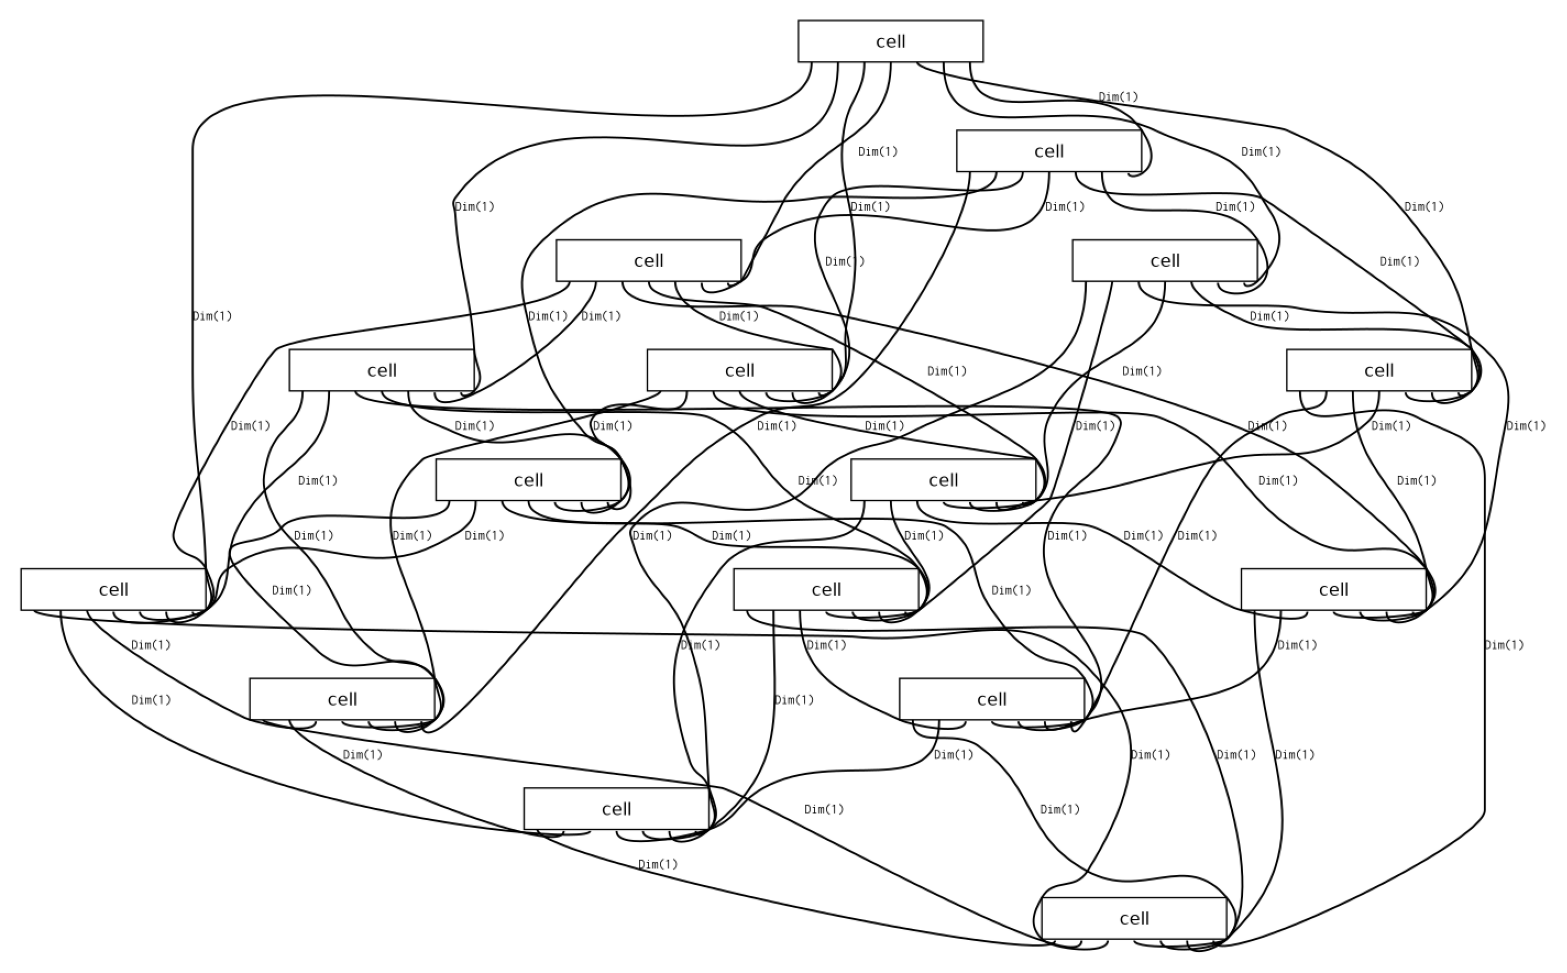

constraints : 28 boxes, 48 wires, non-planar: True


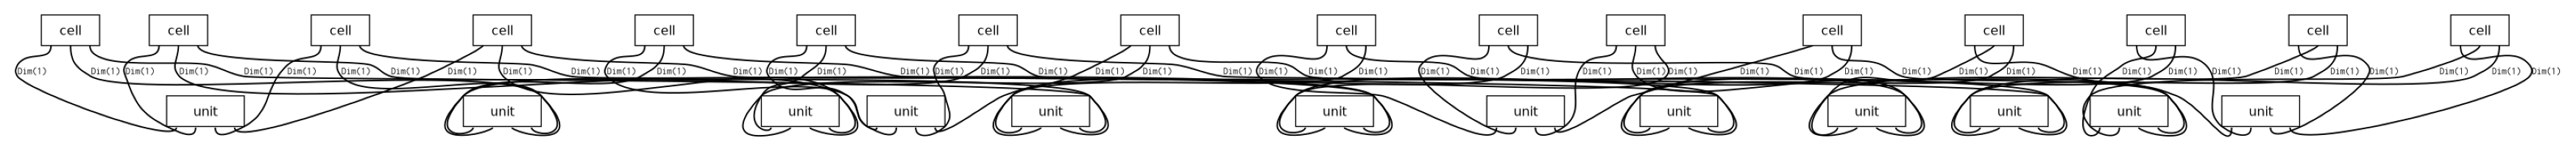

In [10]:


# Both Sudoku encodings as closed combinatorial maps, drawn at 4x4 with
# module-less boxes (only the wiring matters here). The 9x9 grids are the same
# constructions at 81 cells. `ids` gives each cell its (row, column, block).
ids = [(c // 4, c % 4, (c // 4 // 2) * 2 + (c % 4) // 2) for c in range(16)]

# peers: one box per cell, a wire between every pair of peers (a clique per unit).
peers = [tuple(o for o in range(16) if o != c
               and any(a == b for a, b in zip(ids[o], ids[c]))) for c in range(16)]
cell = Network('cell', Dim(0), Dim(1) ** len(peers[0]))
peer_wires = [((c, peers[c].index(o)), (o, peers[o].index(c)))
              for c in range(16) for o in peers[c] if c < o]
grid_peers = CMap.from_wiring(16 * (cell,), peer_wires)

# constraints: one box per cell (3 ports) plus one box per row/column/block unit,
# each cell wired to its three units — a bipartite factor graph.
cons = [(r, 4 + col, 8 + b) for r, col, b in ids]
cell3 = Network('cell', Dim(0), Dim(1) ** 3)
units = [Network('unit', Dim(0), Dim(1) ** 4) for _ in range(12)]
slot = {k: 0 for k in range(12)}; con_wires = []
for c in range(16):
    for j, k in enumerate(cons[c]):
        con_wires.append(((c, j), (16 + k, slot[k]))); slot[k] += 1
grid_cons = CMap.from_wiring(tuple([cell3] * 16 + units), con_wires)

for name, grid in [("peers", grid_peers), ("constraints", grid_cons)]:
    print(f"{name:12s}: {len(grid.boxes):2d} boxes, {grid.n_ports // 2:2d} wires, "
          f"non-planar: {not grid.is_planar}")
    grid.draw()

## 2. Data

In [2]:
# A self-contained Sudoku generator, so the notebook needs no download. It draws a
# random complete grid and then removes clues as long as the solution stays unique.
# Grids are flat length-N*N integer arrays: 0 is a blank cell, 1..N a filled one.
BOX = {4: (2, 2), 6: (2, 3), 9: (3, 3)}          # box shape, box_h * box_w == N

# For each of the N*N cells, precompute the index of its row, its column, and its
# sub-box. These three id arrays are what let us decide whether two cells are peers
# and which unit (row/column/box) a cell belongs to.
def positional_ids(N):
    bh, bw = BOX[N]
    idx = np.arange(N * N)
    row, col = idx // N, idx % N
    box = (row // bh) * (N // bw) + (col // bw)
    return row.astype(np.int32), col.astype(np.int32), box.astype(np.int32)

# Count how many solutions a partially filled grid admits, aborting once `limit`
# solutions (or `node_cap` search nodes) are reached. It is a bitmask backtracking
# search that always branches on the empty cell with the fewest candidates (MRV);
# a return value other than 1 is our test that a puzzle is not uniquely solvable.
def _count(grid, N, rid, cid, bid, limit=2, node_cap=200_000):
    full = (1 << N) - 1
    rows=[0]*N; cols=[0]*N; boxes=[0]*N
    for i in range(N*N):
        v = int(grid[i])
        if v:
            b = 1 << (v-1); rows[rid[i]]|=b; cols[cid[i]]|=b; boxes[bid[i]]|=b
    st = {"c": 0, "n": 0}
    def bt():
        if st["c"] >= limit or st["n"] > node_cap: return
        st["n"] += 1
        best=-1; bm=0; bc=N+1
        for i in range(N*N):
            if grid[i] == 0:
                m = (~(rows[rid[i]]|cols[cid[i]]|boxes[bid[i]])) & full
                c = bin(m).count("1")
                if c == 0: return
                if c < bc: bc, best, bm = c, i, m
                if c == 1: break
        if best == -1: st["c"] += 1; return
        i=best; d=1; mm=bm
        while mm:
            if mm & 1:
                b = 1 << (d-1); grid[i]=d
                rows[rid[i]]|=b; cols[cid[i]]|=b; boxes[bid[i]]|=b
                bt(); grid[i]=0
                rows[rid[i]]&=~b; cols[cid[i]]&=~b; boxes[bid[i]]&=~b
                if st["c"] >= limit or st["n"] > node_cap: return
            mm >>= 1; d += 1
    bt()
    return limit if st["n"] > node_cap else st["c"]

# Fill an empty grid with a single random, valid, complete solution. It is the same
# MRV backtracking as `_count`, but it tries candidate digits in a shuffled order and
# stops at the first full grid, giving a fresh random solved board.
def _complete(N, rid, cid, bid, rng):
    full = (1 << N) - 1
    grid = np.zeros(N*N, np.int8); rows=[0]*N; cols=[0]*N; boxes=[0]*N
    def bt():
        best=-1; bm=0; bc=N+1
        for i in range(N*N):
            if grid[i]==0:
                m=(~(rows[rid[i]]|cols[cid[i]]|boxes[bid[i]]))&full
                c=bin(m).count("1")
                if c==0: return False
                if c<bc: bc,best,bm=c,i,m
                if c==1: break
        if best==-1: return True
        i=best; ds=[d for d in range(1,N+1) if bm&(1<<(d-1))]; rng.shuffle(ds)
        for d in ds:
            b=1<<(d-1); grid[i]=d
            rows[rid[i]]|=b; cols[cid[i]]|=b; boxes[bid[i]]|=b
            if bt(): return True
            grid[i]=0; rows[rid[i]]&=~b; cols[cid[i]]&=~b; boxes[bid[i]]&=~b
        return False
    bt(); return grid

# Turn a solved grid into a puzzle: visit cells in random order and blank each one
# only if the puzzle still has a unique solution, stopping once we are down to
# `givens` clues. Returns the dug puzzle together with its ground-truth solution.
def _dig(N, givens, rid, cid, bid, rng):
    sol = _complete(N, rid, cid, bid, rng); puz = sol.copy()
    order = list(range(N*N)); rng.shuffle(order); have = N*N
    for i in order:
        if have <= givens: break
        saved = puz[i]; puz[i] = 0
        if _count(puz.copy(), N, rid, cid, bid, limit=2) != 1:
            puz[i] = saved
        else:
            have -= 1
    return puz, sol

# Build (or load from the .npz cache) a train/test set of distinct unique-solution
# puzzles. The first call generates `n_train + n_test` de-duplicated puzzles and saves
# them to disk; every later call just reloads the file, so re-running is instant.
def get_sudoku(N=9, n_givens=34, n_train=4000, n_test=1000, seed=0):
    f = os.path.join(DATA, f"sud_N{N}_g{n_givens}_tr{n_train}_te{n_test}_s{seed}.npz")
    if os.path.exists(f):
        d = np.load(f); return d["ptr"], d["str"], d["pte"], d["ste"]
    rid, cid, bid = (a.tolist() for a in positional_ids(N))
    rng = np.random.default_rng(seed); need = n_train + n_test
    seen=set(); P=[]; Sd=[]
    while len(P) < need:
        puz, sol = _dig(N, n_givens, rid, cid, bid, rng)
        k = puz.tobytes()
        if k in seen: continue
        seen.add(k); P.append(puz); Sd.append(sol)
    P = np.stack(P).astype(np.int32); Sd = np.stack(Sd).astype(np.int32)
    ptr, str_, pte, ste = P[:n_train], Sd[:n_train], P[n_train:], Sd[n_train:]
    np.savez(f, ptr=ptr, str=str_, pte=pte, ste=ste)
    return ptr, str_, pte, ste

In [3]:
# Build or load the datasets. `ptr`/`str_` and `pte`/`ste` are the train and test
# (puzzle, solution) arrays for the main 34-given task. `sweep` holds three smaller
# extra-difficulty splits (30/40/50 givens) used only for the difficulty study in
# section 6. Everything is cached, so this cell is slow only on the very first run.
t0 = time.time()
N_TR = 5000 if QUICK else 20000
ptr, str_, pte, ste = get_sudoku(9, n_givens=34, n_train=N_TR, n_test=1500, seed=0)
sweep = {g: get_sudoku(9, n_givens=g, n_train=1500, n_test=400, seed=1)
         for g in (30, 40, 50)}
print(f"ready in {time.time()-t0:.1f}s | train {ptr.shape}, test {pte.shape}, "
      f"number of occupied cells per puzzle ~ {int((ptr>0).sum(1).mean())}")

ready in 0.0s | train (20000, 81), test (1500, 81), number of occupied cells per puzzle ~ 34


## 3. The model: one recurrent cell, iterated

Every cell is the same small module (weight sharing = one categorical
morphism reused $81$ times). It carries a hidden state $h$ on a self-wired port
pair that can be seen as a trace/feedback loop, which makes the cell recurrent with no library
primitive. At each round, it: 

1. pools the messages from its peers (a **mean**, so the update is invariant to
   the order of peers — they are a set),
2. mixes that pool with the injected clue and its current $h$ through a
   `GRUCell`, `LayerNorm`s the result, and
3. emits its new belief on every outgoing wire.

Formally the cell is a map $x^{\otimes P}\otimes h \otimes c \to x^{\otimes P}
\otimes h$. Clues
enter as initial messages, re-injected every round; after the last round a shared
linear head reads each $h$ into $9$ digit logits. We train by cross-entropy
 at a fixed number of rounds $T$ (the head sees
only the final round). Im more simple words, the solver is the trace of a single shared box; learning the
box is learning the local update whose global fixed point is a solved grid.

In [4]:
# The two neural modules that live on the boxes of the map. Both are tiny and shared
# across the whole grid, so the model has the same parameters at any grid size.

# The recurrent variable cell, one shared copy per Sudoku cell. Its input ports are
# laid out as [m_1..m_P peer messages | h, h' state loop | c, c' clue loop]. Each round
# it pools the peer messages with an order-invariant mean, fuses that with the clue and
# its current GRU state, LayerNorm-bounds the update, and re-emits its new belief on
# every peer port while passing the state back through the self-loop.
def gru_cell(dim, state_dim, hidden=None):
    hidden = hidden or 2 * state_dim
    class Cell(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.dim, self.s = dim, state_dim
            self.encode = torch.nn.Sequential(
                torch.nn.Linear(state_dim + dim, hidden), torch.nn.ReLU(),
                torch.nn.Linear(hidden, hidden))
            self.update = torch.nn.GRUCell(hidden + dim, state_dim)
            self.norm = torch.nn.LayerNorm(state_dim)
            self.emit = torch.nn.Linear(state_dim, dim)
        def forward(self, x):
            d, s = self.dim, self.s
            P = (x.shape[-1] - 2*s - 2*d) // d
            msg = x[:, :P*d].reshape(-1, P, d)
            state = x[:, P*d:P*d+s]
            clue = x[:, P*d+2*s:P*d+2*s+d]
            pooled = self.encode(torch.cat([
                state.unsqueeze(1).expand(-1, P, -1), msg], -1)).mean(1)
            state = self.norm(self.update(torch.cat([pooled, clue], -1), state))
            return torch.cat([
                self.emit(state).unsqueeze(1).expand(-1, P, -1).reshape(-1, P*d),
                state, state, torch.zeros_like(clue), torch.zeros_like(clue)], -1)
    return Cell()

# The constraint (factor) box, one shared copy per row/column/block. It reads the K
# member messages of a unit, sum-pools them into a permutation-invariant summary
# (Deep-Sets), and returns to each member a response conditioned on that summary —
# i.e. "here is what the other eight cells in your unit have taken".
def factor_cell(dim, hidden):
    class Factor(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.dim = dim
            self.phi = torch.nn.Sequential(torch.nn.Linear(dim, hidden), torch.nn.ReLU())
            self.rho = torch.nn.Sequential(
                torch.nn.Linear(dim + hidden, hidden), torch.nn.ReLU(),
                torch.nn.Linear(hidden, dim))
        def forward(self, x):
            d = self.dim; K = x.shape[-1] // d
            m = x.reshape(-1, K, d)
            pooled = self.phi(m).sum(1, keepdim=True).expand(-1, K, -1)
            return self.rho(torch.cat([m, pooled], -1)).reshape(-1, K*d)
    return Factor()

In [5]:
# Wire the shared boxes into the two combinatorial maps and wrap either one in the
# full model. `peers` is the pairwise encoding; `constraints` is the factor-graph
# encoding of section 4.

# For each cell, list its peers: the other cells sharing its row, column, or box.
# In a 9x9 grid every cell has exactly 20 peers.
def peers_of(N):
    rid, cid, bid = positional_ids(N)
    return tuple(tuple(sorted(
        o for o in range(N*N) if o != c and (
            rid[o]==rid[c] or cid[o]==cid[c] or bid[o]==bid[c])))
        for c in range(N*N))

# The pairwise map. Every cell is one shared recurrent box whose ports are P peer
# messages plus a state loop and a clue loop. We add one wire between each pair of
# peers and close the two self-loops, then assemble everything into a closed CMap.
def build_peers(N, dim, state_dim):
    peers = peers_of(N); P = len(peers[0]); ncell = N*N
    cell = Network('cell', Dim(0),
                   Dim(dim)**P @ Dim(state_dim)**2 @ Dim(dim)**2,
                   module=gru_cell(dim, state_dim))
    wires = [((c, peers[c].index(o)), (o, peers[o].index(c)))
             for c in range(ncell) for o in peers[c] if c < o]
    for c in range(ncell):
        wires += [((c, P), (c, P+1)), ((c, P+2), (c, P+3))]
    return CMap.from_wiring(ncell*(cell,), wires), P

# The factor-graph map. Each cell now keeps only three message ports (one per unit)
# and is wired to its row, column, and block boxes; the 3N unit boxes all share a
# single factor module, and `slot` tracks the next free port on each as we connect its
# nine members. This roughly halves the wire count versus `peers`.
def build_constraints(N, dim, state_dim):
    ncell = N*N; rid, cid, bid = positional_ids(N)
    cons = [(int(rid[c]), N+int(cid[c]), 2*N+int(bid[c])) for c in range(ncell)]
    cell = Network('cell', Dim(0),
                   Dim(dim)**3 @ Dim(state_dim)**2 @ Dim(dim)**2,
                   module=gru_cell(dim, state_dim))
    shared = factor_cell(dim, 2*state_dim)
    factors = [Network('con', Dim(0), Dim(dim)**N, module=shared) for _ in range(3*N)]
    slot = {k: 0 for k in range(3*N)}; wires = []
    for c in range(ncell):
        for j, k in enumerate(cons[c]):
            wires.append(((c, j), (ncell + k, slot[k]))); slot[k] += 1
        wires += [((c, 3), (c, 4)), ((c, 5), (c, 6))]
    return CMap.from_wiring(tuple([cell]*ncell + factors), wires), 3

# The end-to-end model. It embeds each clue digit, injects it on the matching cell's
# clue loop, runs the chosen map for `n_rounds` of message passing, and decodes a digit
# distribution from every cell's hidden state with a shared linear head. A forward call
# takes a (B, ncell) clue grid and returns (B, ncell, N) logits — or a list of them, one
# per round, when `deep=True`.
class Solver(torch.nn.Module):
    def __init__(self, dim=24, state_dim=96, n_rounds=20, encoding="constraints", N=9):
        super().__init__()
        self.N, self.dim, self.s, self.n_rounds = N, dim, state_dim, n_rounds
        build = build_constraints if encoding == "constraints" else build_peers
        self.grid, self.P = build(N, dim, state_dim)
        self.ncell = N*N
        self.cells = self.grid.as_network().module
        self.embedding = torch.nn.Embedding(N+1, dim)
        self.readout = torch.nn.Linear(state_dim, N)
        self.clue_ports = [self.grid.box_ports(c)[-2:] for c in range(self.ncell)]

    def forward(self, clues, deep=False, n_rounds=None):
        emb = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for c in range(self.ncell):
            for port in self.clue_ports[c]:
                init[port] = emb[:, c, :]
        off = self.P * self.dim
        rounds = self.cells(init=init, n_rounds=n_rounds or self.n_rounds,
                            return_rounds=deep)
        def head(states):
            h = torch.stack([states[c][:, off:off+self.s] for c in range(self.ncell)], 1)
            return self.readout(h)
        return [head(st) for st in rounds] if deep else head(rounds)

In [6]:
# Evaluate a model over a dataset. For each board we overwrite the predictions on the
# given cells with the clues themselves, then report two numbers: the mean fraction of
# cells that are correct, and the fraction of boards that are entirely correct.
@torch.no_grad()
def accuracy(model, puz, sol, n_rounds=None, bs=512):
    model.eval(); cell_ok = board_ok = tot = 0
    for i in range(0, len(puz), bs):
        clues = torch.as_tensor(puz[i:i+bs], dtype=torch.long, device=device)
        pred = model(clues, n_rounds=n_rounds).argmax(-1) + 1
        pred = torch.where(clues > 0, clues, pred)
        tgt = torch.as_tensor(sol[i:i+bs], dtype=torch.long, device=device)
        ok = pred == tgt
        cell_ok += ok.float().mean(1).sum().item()
        board_ok += ok.all(1).sum().item(); tot += len(clues)
    return cell_ok/tot, board_ok/tot

# The training loop: plain Adam on cross-entropy against the solution. With deep=False
# the loss is taken on the final round only, with deep=True it is averaged over every
# round. We evaluate on the test set after each epoch and return a per-epoch dataframe
# of loss and accuracy, which the plots below consume.
def train(model, puz, sol, pte, ste, epochs=12, bs=128, lr=1e-3, deep=False, log=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X = torch.as_tensor(puz, dtype=torch.long)
    Y = torch.as_tensor(sol, dtype=torch.long) - 1
    hist = []
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(X)); t = time.time(); run = 0.0
        for i in range(0, len(perm), bs):
            idx = perm[i:i+bs]; clues = X[idx].to(device); tgt = Y[idx].to(device)
            opt.zero_grad()
            if deep:
                outs = model(clues, deep=True)
                loss = sum(torch.nn.functional.cross_entropy(
                    o.reshape(-1, model.N), tgt.reshape(-1)) for o in outs) / len(outs)
            else:
                loss = torch.nn.functional.cross_entropy(
                    model(clues).reshape(-1, model.N), tgt.reshape(-1))
            loss.backward(); opt.step(); run += loss.item()
        ca, ba = accuracy(model, pte, ste)
        hist.append({"epoch": ep+1, "loss": run/(len(perm)//bs+1), "cell": ca, "board": ba})
        if log:
            print(f"  ep {ep+1:2d}  loss {hist[-1]['loss']:.3f}  cell {ca:.3f}  "
                  f"board {ba:.3f}  ({time.time()-t:.0f}s)")
    return pd.DataFrame(hist)

## 4. Constraints as boxes: from clique to hyperedge

For as much as we do not love rigid hierarchies in society, we have to admit it is a very nice kind of "sparsity" when it comes to transfer information. Apparently, sudokus confirms that: instead of 36 whispered pairwise "we must differ", we let each unit (a block/row/column) have a 'representative' who sees all nine cells at once and tells each what the others have taken. A row (or column, or block) is really
one relation over nine cells. So give each of the $27$ units its own box: a
permutation-equivariant $R:\,x^{\otimes 9}\to x^{\otimes 9}$
that pools its nine members ($\phi$ then sum) and returns to each a response
$\rho(\text{message},\,\text{pool})$. Wiring every cell to its three unit boxes
turns the graph into a bipartite factor graph.

Concretely this cuts the wire count from $972$ to $405$ (about half) while keeping
the identical tiny cell, and the vectorized `forward` runs the cell-boxes and
factor-boxes as two batched groups with no special-casing. We will later see that they also reach the same accuracy, but with a cost: the hierarchical model needs more iterations to reach the same test accuracy. So, less heavy on memory, more on inference time. 

In [7]:
# Train both encodings on the 34-given task under the same budget: EP_MAIN epochs and
# R_TRAIN message-passing rounds. We first print each map's size — note both share the
# same tiny weight set while `constraints` uses far fewer wires — then train the
# pairwise `peers` model and the factor-graph `constraints` model.
EP_MAIN = 12 if QUICK else 22
R_TRAIN = 20

print("cells share ONE small, grid-size-independent weight set:")
for enc in ("peers", "constraints"):
    m = Solver(encoding=enc)
    print(f"  {enc:12s}: {len(m.grid.boxes):3d} boxes, {m.grid.n_ports//2:4d} "
          f"wires, {sum(p.numel() for p in m.parameters()):,} params")

print("\npeers @ 34 givens:")
m_peers = Solver(encoding="peers", n_rounds=R_TRAIN)
h_peers = train(m_peers, ptr, str_, pte, ste, epochs=EP_MAIN)
print("constraints @ 34 givens:")
m_cons = Solver(encoding="constraints", n_rounds=R_TRAIN)
h_cons = train(m_cons, ptr, str_, pte, ste, epochs=EP_MAIN)

cells share ONE small, grid-size-independent weight set:
  peers       :  81 boxes,  972 wires, 154,353 params
  constraints : 108 boxes,  405 wires, 205,449 params

peers @ 34 givens:
  ep  1  loss 1.093  cell 0.775  board 0.000  (30s)
  ep  2  loss 0.414  cell 0.901  board 0.053  (32s)
  ep  3  loss 0.199  cell 0.953  board 0.523  (32s)
  ep  4  loss 0.133  cell 0.964  board 0.589  (31s)
  ep  5  loss 0.098  cell 0.967  board 0.673  (31s)
  ep  6  loss 0.085  cell 0.976  board 0.740  (31s)
  ep  7  loss 0.074  cell 0.981  board 0.832  (31s)
  ep  8  loss 0.072  cell 0.980  board 0.811  (31s)
  ep  9  loss 0.060  cell 0.981  board 0.807  (31s)
  ep 10  loss 0.057  cell 0.981  board 0.820  (31s)
  ep 11  loss 0.058  cell 0.984  board 0.832  (31s)
  ep 12  loss 0.052  cell 0.986  board 0.856  (31s)
  ep 13  loss 0.044  cell 0.983  board 0.814  (31s)
  ep 14  loss 0.048  cell 0.984  board 0.851  (31s)
  ep 15  loss 0.038  cell 0.986  board 0.865  (31s)
  ep 16  loss 0.038  cell 0.988  bo

## 5. Training and inference dynamics

Four views of the same run. The top row watches the loss and the
fraction of fully solved boards per epoch. The bottom row watches inference as
a dynamical system: the residual $\|h_{t+1}-h_t\|$ along a single forward pass,
and what happens when we run more rounds at test time than we trained on.

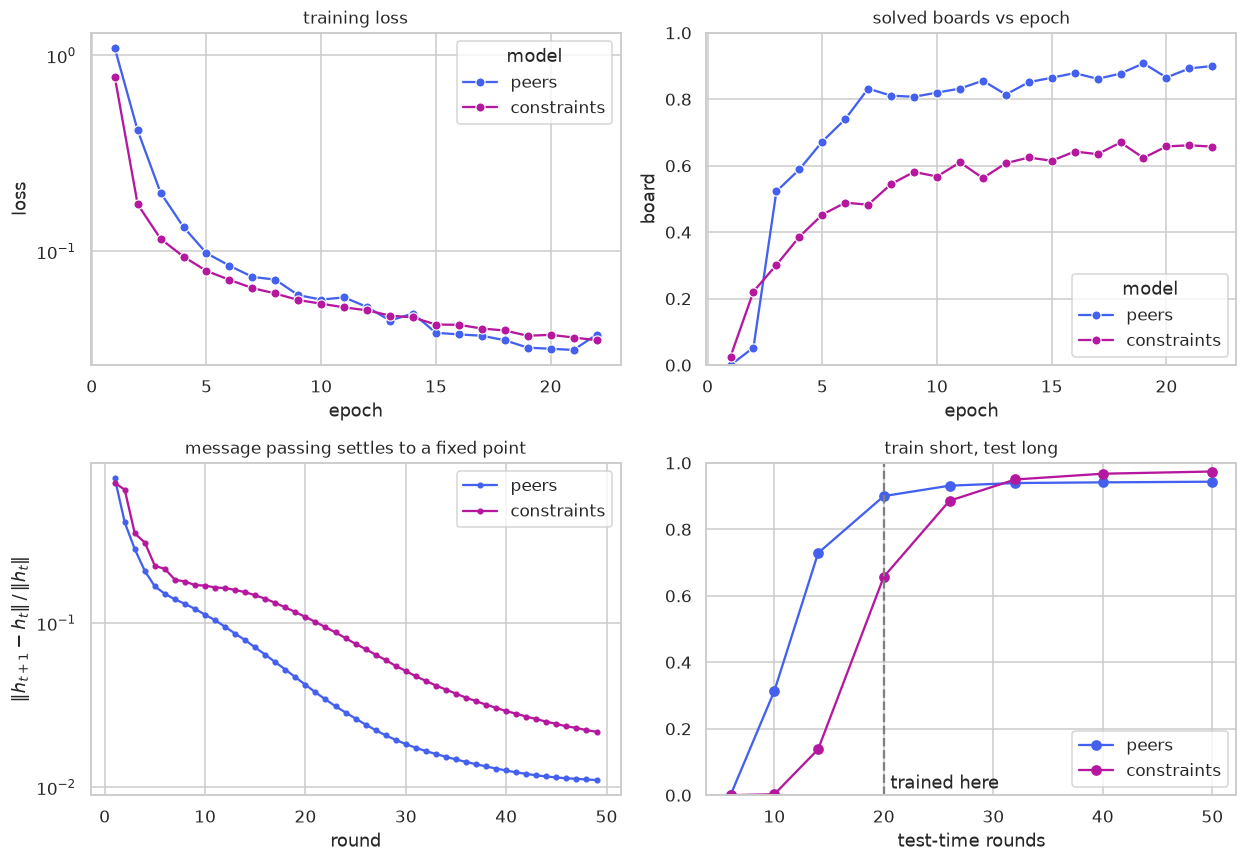

best constraints: board 0.974 at 50 test rounds (trained at 20)


In [8]:
# The section-5 dashboard: three small helpers that measure the inference dynamics,
# followed by a 2x2 figure combining their outputs for both models.

# Run one forward pass but keep every round, returning the stacked cell hidden states
# with shape (T, B, ncell, state_dim). Clues are injected exactly as in the model.
@torch.no_grad()
def state_trace(model, clues, T):
    emb = model.embedding(clues)
    init = [None] * model.grid.n_ports
    for c in range(model.ncell):
        for port in model.clue_ports[c]:
            init[port] = emb[:, c, :]
    off = model.P * model.dim
    rounds = model.cells(init=init, n_rounds=T, return_rounds=True)
    return torch.stack([
        torch.stack([r[c][:, off:off+model.s] for c in range(model.ncell)], 1)
        for r in rounds], 0)

# Measure how much the state still moves from round to round: the mean relative step
# ‖h_{t+1} - h_t‖ / ‖h_t‖. If the cell is a contraction this decays toward zero, the
# empirical signature of the message passing settling onto a fixed point.
@torch.no_grad()
def residual_curve(model, puz, T=50, bs=512):
    clues = torch.as_tensor(puz[:bs], dtype=torch.long, device=device)
    H = state_trace(model, clues, T)
    num = (H[1:] - H[:-1]).flatten(2).norm(dim=-1)
    den = H[:-1].flatten(2).norm(dim=-1).clamp_min(1e-9)
    return (num / den).mean(1).cpu().numpy()

# Sweep the number of test-time rounds and record cell and board accuracy at each, to
# see whether running longer than we trained keeps helping.
def tt_curve(model, rounds):
    return pd.DataFrame([
        dict(rounds=r, **dict(zip(("cell", "board"),
             accuracy(model, pte, ste, n_rounds=r)))) for r in rounds])

# Compute the four curves for both models and draw the 2x2 dashboard: training loss and
# solved-boards per epoch on the top row, the per-round residual and accuracy-vs-test-
# time-rounds on the bottom row. The dashed line marks the round count we trained at, so
# anything to its right is extrapolation we never optimised for.
rounds_grid = [6, 10, 14, 20, 26, 32, 40, 50]
tt_cons = tt_curve(m_cons, rounds_grid); tt_peers = tt_curve(m_peers, rounds_grid)
res_cons = residual_curve(m_cons, pte); res_peers = residual_curve(m_peers, pte)

hist = pd.concat([h_peers.assign(model="peers"), h_cons.assign(model="constraints")])
pal = {"peers": "#4361ee", "constraints": "#b5179e"}

fig, ax = plt.subplots(2, 2, figsize=(11.5, 8))
sns.lineplot(hist, x="epoch", y="loss", hue="model", palette=pal, marker="o", ax=ax[0,0])
ax[0,0].set_yscale("log"); ax[0,0].set_title("training loss")

sns.lineplot(hist, x="epoch", y="board", hue="model", palette=pal, marker="o", ax=ax[0,1])
ax[0,1].set_ylim(0, 1); ax[0,1].set_title("solved boards vs epoch")

for name, r in [("peers", res_peers), ("constraints", res_cons)]:
    ax[1,0].plot(np.arange(1, len(r)+1), r, marker=".", color=pal[name], label=name)
ax[1,0].set_yscale("log"); ax[1,0].set_xlabel("round")
ax[1,0].set_ylabel(r"$\|h_{t+1}-h_t\| \,/\, \|h_t\|$")
ax[1,0].set_title("message passing settles to a fixed point"); ax[1,0].legend()

for name, tt in [("peers", tt_peers), ("constraints", tt_cons)]:
    ax[1,1].plot(tt["rounds"], tt["board"], marker="o", color=pal[name], label=name)
ax[1,1].axvline(R_TRAIN, ls="--", color="0.5")
ax[1,1].text(R_TRAIN+.6, 0.02, "trained here")
ax[1,1].set_xlabel("test-time rounds"); ax[1,1].set_ylim(0, 1)
ax[1,1].set_title("train short, test long"); ax[1,1].legend()
plt.tight_layout(); plt.show()

best = tt_cons.sort_values("board").iloc[-1]
print(f"best constraints: board {best.board:.3f} at {int(best.rounds)} test rounds "
      f"(trained at {R_TRAIN})")

**Conclusion**

The two models train very similarly in terms of final test accuracy. The dense one is much better at reaching an equilibrium state, and at reaching a good accuracy during training (with T = 20). However, the sparse/hierarchical model catches up when using extra iterations at test time (this is interesting, and a cool property of GNNs: you can train with T = 20, and it learns to improve with T = 50, even if it has never seen this high number of iterations during traing). This is also a property of fixed point models: because inference *is* that contraction, running more rounds than we trained on keeps improving accuracy for free, saturating near the fixed point. 